In [56]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1


# Multishank sessions only
multishank_mouse_days = {
    21: [15,16,17,18,22],
    20: [14,15,16,17,18,19],
    22: [37,38,39,40,41,42,43,44],
    25: [16,17,18,25,26],
    26: [13,15,16,19,20,21,22],
    27: [18,19,23,24,26],
    28: [16,17,18,23],
    29: [16,17,18,20,23,25],
}

multishank_mouse_days = {
    27: [23,24,26],
    25: [24, 25],
    26: [19],
    28: [23],    
}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import numpy as np

def make_annotations(mouse, path=None):
    Mouse = f'M{mouse}'

    data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
    shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
    clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
    clusters_df = clusters_df[clusters_df['mouse'] == mouse]
    shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
    clusters_df = reconstruct_shank_id(clusters_df, mouse)
    probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
    adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)
    
    ymin = -300; ymax = 3000
    xmin = -200; xmax = 1000
    xs = np.arange(xmin, xmax, 1)
    ys = np.arange(ymin, ymax, 1)

    if os.path.exists(f"{path}/M{mouse}_annotations.npy"):
        # Load annotations and colors from disk
        annotations = np.load(f"{path}/M{mouse}_annotations.npy", allow_pickle=True)
        annotation_colors = np.load(f"{path}/M{mouse}_annotation_colors.npy", allow_pickle=True)
        return annotations, annotation_colors, xs, ys
    
    else:
        annotations = np.zeros((len(ys), len(xs)), dtype=object)
        for yi, y in enumerate(ys):
            for xi, x in enumerate(xs):
                coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
                z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
                annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
                if len(structure_set[structure_set['id'] == annotation_index]) ==1:
                    annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
                else:
                    annotation ='root' # out of brain
                annotations[yi,xi] = annotation

        annotation_colors = get_annotation_colors_2D(annotations)

        # Save
        np.save(f"{path}/M{mouse}_annotations.npy", annotations)
        np.save(f"{path}/M{mouse}_annotation_colors.npy", annotation_colors)

    return annotations, annotation_colors, xs, ys

In [58]:
def plot_cells_on_annotated_probe(mouse, day, gcs, ngs, all_cells, path='/Users/harryclark/Documents/spatial-manifolds/data'):
    """
    Plot GCS and NGS cells on the annotated probe map for a given mouse and day.
    GCS cells are shown in red, NGS cells in blue, all other cells in gray.
    """
    print(f'printing probe map for Mouse {mouse} Day {day} with {len(gcs)} GCS cells, {len(ngs)} NGS cells, and {len(all_cells)} total cells')
    # Load annotations and colors
    annotations, annotation_colors, xs, ys = make_annotations(mouse, path=path)
    unique_colors = np.unique(annotation_colors)
    
    fig, ax = plt.subplots(figsize=(6, 10))
    # Plot annotation background
    for color_ in unique_colors:
        border_points = extract_border(annotation_colors, color_, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax.scatter(x_points, y_points, color=color_, s=1, rasterized=True)
    plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa',
                   probe_alpha=0.5, contacts_alpha=0.5, probe_color='grey', probe_edgecolor='black')
    
    # Plot all cells in gray
    ax.scatter(all_cells.probe_x.values, all_cells.probe_y.values, marker='o', color="grey", alpha=0.3, s=10, label='All')
    if len(ngs) > 0:
        ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color='#3171ae', alpha=0.7, s=30, label='NGS')
    if len(gcs) > 0:
        ax.scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color='#c04744', alpha=0.7, s=30, label='GCS')
    
    ax.set_ylim([0, 3000])
    ax.set_xlim([-100, 900])
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M{mouse}D{day}_probe_map.pdf')
    plt.close()

for mouse, days in multishank_mouse_days.items():
    for day in days:
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse=mouse, day=day, percentile_threshold=95, verbose=False)
        plot_cells_on_annotated_probe(mouse, day, gcs, ngs, all)


printing probe map for Mouse 27 Day 23 with 8 GCS cells, 69 NGS cells, and 80 total cells
hi
printing probe map for Mouse 27 Day 24 with 4 GCS cells, 137 NGS cells, and 145 total cells
hi
printing probe map for Mouse 27 Day 26 with 5 GCS cells, 13 NGS cells, and 19 total cells
hi
printing probe map for Mouse 25 Day 24 with 22 GCS cells, 37 NGS cells, and 63 total cells
hi
printing probe map for Mouse 25 Day 25 with 33 GCS cells, 56 NGS cells, and 108 total cells
hi
printing probe map for Mouse 26 Day 19 with 32 GCS cells, 217 NGS cells, and 280 total cells
hi
printing probe map for Mouse 28 Day 23 with 7 GCS cells, 97 NGS cells, and 137 total cells
hi


In [59]:
import numpy as np

def make_hit_mask(beh, trial_types):
    """
    Build a boolean mask over trials marking hits for specific trial types.

    Parameters
    ----------
    beh : dict-like
        Behaviour output from compute_vr_tcs; expects beh['trials']
        with at least columns 'type' and 'hit'.
    trial_types : str, int, or list/tuple of these
        Trial type(s) to include (e.g. 'b', 'nb', or ['b', 'nb']).

    Returns
    -------
    mask : np.ndarray of bool, shape (n_trials,)
        True where trial is one of the requested types AND hit == 1,
        False otherwise.
    """
    trials = beh['trials']

    # Normalise trial_types to a list
    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]

    # Mask for requested types
    type_mask = trials['type'].isin(trial_types)

    # Mask for hits (assuming 1 = hit)
    hit_mask = trials['performance'] == 'hit'

    # Combined mask; length == number of rows in beh['trials']
    mask = (type_mask & hit_mask).to_numpy()

    return mask

def make_trialtype_mask(beh, trial_types):
    """
    Boolean mask over trials marking where the trial type is in trial_types,
    regardless of performance (hit/miss/etc.).
    """
    trials = beh['trials']

    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]

    type_mask = trials['type'].isin(trial_types)
    return type_mask.to_numpy()


Processing Mouse 27 Day 23...
8 GCS cells, 69 NGS cells, 80 total cells
Error processing cluster 318 on shank 2: all input arrays must have the same shape


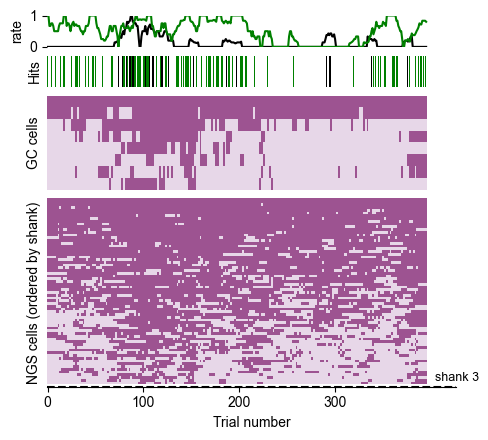

Processing Mouse 27 Day 26...
5 GCS cells, 13 NGS cells, 19 total cells


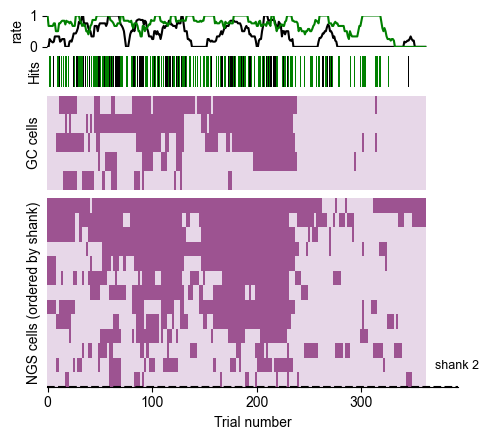

Processing Mouse 25 Day 24...
22 GCS cells, 37 NGS cells, 63 total cells
Error processing cluster 120 on shank 0: all input arrays must have the same shape


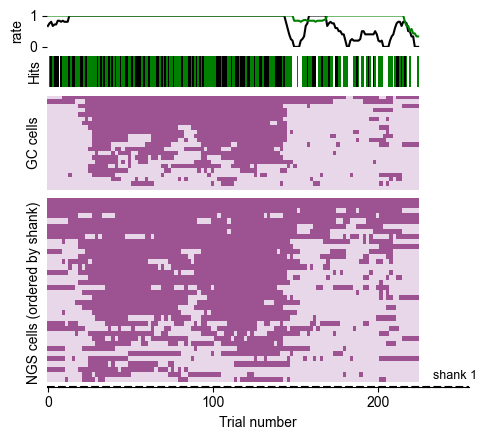

Processing Mouse 25 Day 25...
33 GCS cells, 56 NGS cells, 108 total cells


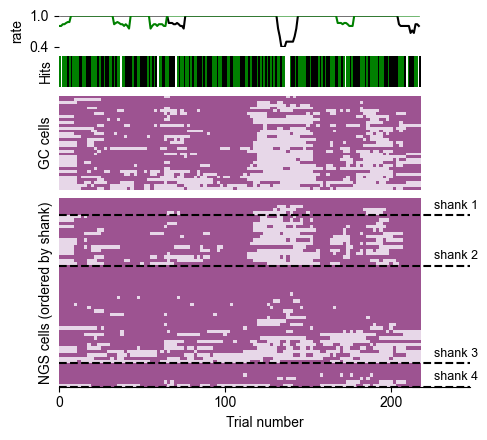

Processing Mouse 26 Day 19...
32 GCS cells, 217 NGS cells, 280 total cells


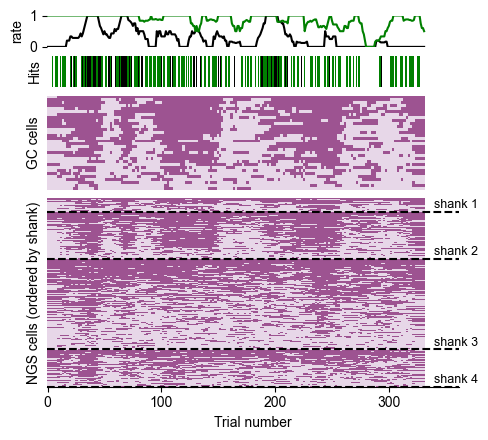

Processing Mouse 28 Day 23...
7 GCS cells, 97 NGS cells, 137 total cells
Error processing cluster 368 on shank 3: all input arrays must have the same shape


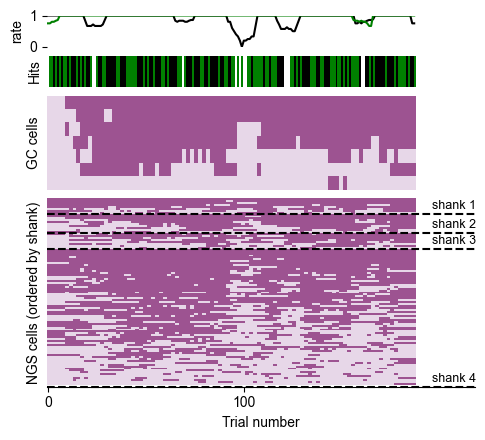

In [77]:

multishank_mouse_days = {
    27: [23,26],
    25: [24,25],
    26: [19],
    28: [23],    
}

# --- Raster plot of task_anchored_labels for all cells, ordered by shank,
#     with rolling hit rate on top, HIT row below, then GCS and NGS rasters ---
for mouse, days in multishank_mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")
        
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(
            mouse=mouse, day=day, percentile_threshold=95, verbose=False
        )
        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
            mouse, day, apply_zscore=False, apply_guassian_filter=False
        )
        last_ephys_time_bin = clusters[clusters.index[0]].count(
            bin_size=time_bs, time_units='ms'
        ).index[-1]
        print(f'{len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all)} total cells')

        # Compute GCS task-anchored label rasters (ordered as in gcs DataFrame)
        gcs_labels = []
        gcs_rate_maps = []
        for cluster_id in gcs.cluster_id.values:
            try:
                tc = tcs[cluster_id] if cluster_id in tcs else None
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]
                tcs_to_use = {cluster_id: tc}
                tcs_to_use[1000] = tc

                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                spectrograms = results[3]
                fvalid = results[5]
                S = spectrograms.mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
                gcs_labels.append(labels)
                gcs_rate_maps.append(tc)
            except Exception as e:
                print(f"Error processing GCS cluster {cluster_id}: {e}")

        # Sort GCS by task-anchored sum descending
        gcs_label_sums = np.array([np.nansum(lab == 1) for lab in gcs_labels])
        gcs_sort_order = np.argsort(-gcs_label_sums)
        gcs_labels = [gcs_labels[i] for i in gcs_sort_order]
        gcs_rate_maps = [gcs_rate_maps[i] for i in gcs_sort_order]

        # Group NGS cells by shank
        ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
        shank_ids = sorted(ngs['shank_id'].unique())
        ngs_cells_by_shank = {
            shank: ngs[ngs['shank_id'] == shank].cluster_id.values
            for shank in shank_ids
        }

        # Flatten all cells, keeping shank info
        global_cell_list = []
        global_shank_list = []
        for shank in shank_ids:
            for cid in ngs_cells_by_shank[shank]:
                global_cell_list.append(cid)
                global_shank_list.append(shank)

        # Compute NGS task-anchored label rasters, ordered by shank
        avg_rate_maps = []
        all_labels = []
        cell_ids_ordered = []
        cell_shank_order = []

        for idx, (target_cluster_id, shank) in enumerate(
            zip(global_cell_list, global_shank_list)
        ):
            try:
                tcs_to_use = {
                    cluster_id: tcs[cluster_id]
                    for cluster_id in [target_cluster_id]
                    if cluster_id in tcs
                }
                tcs_to_use[1000] = tcs_to_use[target_cluster_id]

                tc = tcs[target_cluster_id]
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]

                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                spectrograms = results[3]
                fvalid = results[5]
                S = spectrograms.mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
            
            except Exception as e:
                print(f"Error processing cluster {target_cluster_id} on shank {shank}: {e}")
                labels = np.full_like(labels, np.nan)

            avg_rate_maps.append(tc)
            cell_shank_order.append(shank)
            all_labels.append(labels)
            cell_ids_ordered.append(target_cluster_id)

        # Sort within each shank by task-anchored sum descending
        shank_arr = np.array(cell_shank_order)
        label_sums = np.array([np.nansum(lab == 1) for lab in all_labels])
        order = []
        for shank in shank_ids:
            shank_indices = np.where(shank_arr == shank)[0]
            sorted_shank = shank_indices[np.argsort(-label_sums[shank_indices])]
            order.extend(sorted_shank.tolist())
        order = np.array(order)

        # Pad both GCS and NGS label matrices to the same number of columns
        max_len = max(
            [len(lab) for lab in all_labels] + [len(lab) for lab in gcs_labels]
        )
        labels_matrix_ngs = np.full((len(all_labels), max_len), np.nan)
        for i, lab in enumerate([all_labels[idx] for idx in order]):
            labels_matrix_ngs[i, :len(lab)] = lab

        labels_matrix_gcs = np.full((len(gcs_labels), max_len), np.nan)
        for i, lab in enumerate(gcs_labels):
            labels_matrix_gcs[i, :len(lab)] = lab

        # ------------------------------------------------------------------
        # Build a 1×max_len raster row for HIT TRIALS using make_hit_mask:
        # ------------------------------------------------------------------
        nb_hit_mask = make_hit_mask(beh, 'nb')
        b_hit_mask  = make_hit_mask(beh, 'b')
        nb_type_mask = make_trialtype_mask(beh, 'nb')
        b_type_mask  = make_trialtype_mask(beh, 'b')

        n_trials = len(nb_hit_mask)
        n_use = min(max_len, n_trials)

        trial_hit_type = np.zeros(max_len, dtype=int)
        trial_hit_type[:n_use][nb_hit_mask[:n_use]] = 1
        trial_hit_type[:n_use][b_hit_mask[:n_use]] = 2

        hit_matrix = np.full((1, max_len), np.nan)
        hit_matrix[0, trial_hit_type == 1] = 0
        hit_matrix[0, trial_hit_type == 2] = 1

        # ------------------------------------------------------------------
        # Rolling average of hit rate for NB and B trials
        # ------------------------------------------------------------------
        window = 10
        kernel = np.ones(window) / window

        nb_hits   = nb_hit_mask.astype(float)
        b_hits    = b_hit_mask.astype(float)
        nb_trials = nb_type_mask.astype(float)
        b_trials  = b_type_mask.astype(float)

        nb_num = np.convolve(nb_hits,   kernel, mode='same')
        nb_den = np.convolve(nb_trials, kernel, mode='same')
        b_num  = np.convolve(b_hits,    kernel, mode='same')
        b_den  = np.convolve(b_trials,  kernel, mode='same')

        nb_rolling = np.full_like(nb_num, np.nan, dtype=float)
        b_rolling  = np.full_like(b_num,  np.nan, dtype=float)
        nb_rolling[nb_den > 0] = nb_num[nb_den > 0] / nb_den[nb_den > 0]
        b_rolling[b_den > 0]   = b_num[b_den > 0]   / b_den[b_den > 0]

        nb_rolling_full = np.full(max_len, np.nan)
        b_rolling_full  = np.full(max_len, np.nan)
        nb_rolling_full[:n_use] = nb_rolling[:n_use]
        b_rolling_full[:n_use]  = b_rolling[:n_use]

        from matplotlib.colors import ListedColormap, BoundaryNorm

        cmap_hits = ListedColormap(["black", "green", "white"])
        norm_hits = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_hits.N)
        cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
        norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

        fig, axes = plt.subplots(
            4, 1, figsize=(5, 4.5), sharex=True,
            gridspec_kw={'height_ratios': [1, 1, 3, 6]}
        )

        axes[0].plot(nb_rolling_full, color='black', label='NB hit rate')
        axes[0].plot(b_rolling_full,  color='green', label='B hit rate')
        axes[0].set_ylabel('rate')

        y_vals = np.concatenate([nb_rolling_full, b_rolling_full])
        finite = np.isfinite(y_vals)
        if finite.any():
            y_min, y_max = y_vals[finite].min(), y_vals[finite].max()
            if y_min == y_max:
                margin = 0.05 * (abs(y_min) if y_min != 0 else 1.0)
                y_min -= margin; y_max += margin
        else:
            y_min, y_max = 0.0, 1.0
        axes[0].set_ylim(y_min, y_max)
        axes[0].set_yticks(np.linspace(y_min, y_max, 2))
        for spine in axes[0].spines.values(): spine.set_visible(False)
        axes[0].tick_params(left=True, bottom=False, labelbottom=False)

        axes[1].imshow(hit_matrix, aspect='auto', cmap=cmap_hits, norm=norm_hits,
                       interpolation='nearest', rasterized=False)
        axes[1].set_ylabel('Hits')
        axes[1].set_yticks([])
        for spine in axes[1].spines.values(): spine.set_visible(False)
        axes[1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        axes[2].imshow(labels_matrix_gcs, aspect='auto', cmap=cmap, norm=norm,
                       interpolation='nearest', rasterized=False)
        axes[2].set_ylabel('GC cells')
        axes[2].set_yticks([])
        for spine in axes[2].spines.values(): spine.set_visible(False)
        axes[2].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        axes[3].imshow(labels_matrix_ngs, aspect='auto', cmap=cmap, norm=norm,
                       interpolation='nearest', rasterized=False)
        axes[3].set_xlabel('Trial number')
        axes[3].set_ylabel('NGS cells (ordered by shank)')
        axes[3].set_yticks([])
        for spine in axes[3].spines.values(): spine.set_visible(False)
        axes[3].tick_params(left=False, bottom=True, labelleft=False, labelbottom=True)

        shank_counts = [np.sum(np.array(cell_shank_order)[order] == shank) for shank in shank_ids]
        shank_ends = np.cumsum(shank_counts)
        xmax = labels_matrix_ngs.shape[1]
        for i, (shank, y) in enumerate(zip(shank_ids, shank_ends)):
            axes[3].hlines(y - 0.5, xmin=-0.5, xmax=xmax + 30,
                           color='black', linewidth=1.5, linestyle='dashed', clip_on=False)
            axes[3].text(xmax + 8, y - 0.5 - 1, f'shank {shank + 1}',
                         fontsize=9, va='bottom', ha='left', clip_on=False)

        axes[3].set_xlim([-0.5, xmax + 30])
        axes[3].spines["bottom"].set_visible(True)
        xticks = list(range(0, xmax + 1, 100))
        axes[3].set_xticks(xticks)
        axes[3].set_xticklabels(xticks)

        plt.tight_layout()
        plt.subplots_adjust(hspace=0.1)
        plt.savefig(
            f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
            f'figure_6_task_anchoring/M{mouse}D{day}_TA_raster_with_hits.pdf',
            dpi=1000
        )
        plt.show()


In [67]:
mice = [26, 
        25] 
days = [19, 
        25]
example_cluster_ids = [[201, 58, 95, 327, 438],
                       [83, 1, 102, 174, 284]]
example_cluster_labels = [['GCS', 'NGS', 'NGS', 'NGS', 'NGS'],
                          ['GCS', 'NGS', 'NGS', 'NGS', 'NGS']]
example_cluster_colors = [['#69201a', '#0d2958', '#0d2958', '#0d2958', '#0d2958'],
                          ['#69201a', '#0d2958', '#0d2958', '#0d2958', '#0d2958']]

In [62]:
def get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=False):
    trial_numbers = np.array(beh['trial_number'])
    position = np.array(beh['P'])
    speed = np.array(beh['S'])
    trial_numbers = trial_numbers[:len(speed)]
    position = position[:len(speed)]

    n_pos_bins = int(tl / 5)
    pos_bins = np.linspace(0, tl, n_pos_bins + 1)

    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    if sort:
        sorted_cats = trial_df.groupby(by=['context', 'type', 'performance'])
        sorted_trial_indices = []
        for _, cat_df in sorted_cats:
            sorted_trial_indices.extend(cat_df.index.tolist())
        trial_order = sorted_trial_indices
    else:
        trial_order = trial_df.index.tolist()

    speed_matrix = np.full((len(trial_order), n_pos_bins), np.nan)
    trial_type_colors = []
    for i, ti in enumerate(trial_order):
        trial_num = trial_df['number'][ti]
        mask = (trial_numbers == trial_num)
        pos_trial = position[mask]
        speed_trial = speed[mask]
        bin_sums, _ = np.histogram(pos_trial, bins=pos_bins, weights=speed_trial)
        bin_counts, _ = np.histogram(pos_trial, bins=pos_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            speed_profile = bin_sums / bin_counts
        speed_matrix[i, :] = speed_profile
        trial_type = trial_df['type'][ti]
        color = get_color_for_group(('rz1', trial_type, 'hit')) if isinstance(trial_type, str) else 'grey'
        trial_type_colors.append(color)
    return speed_matrix, trial_type_colors, trial_order, pos_bins


def sem_nan(a, axis=0):
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    return np.where(n > 1, std / np.sqrt(n), np.nan)


def trial_type_stats_from_speed_matrix(beh, last_ephys_bin, tl, bs, speed_matrix, trial_order):
    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    trial_types_order = [trial_df.loc[int(ti), 'type'] for ti in trial_order]
    pos_bins = np.linspace(0, tl, int(tl / 5) + 1)
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2
    unique_types = [t for t in np.unique(np.array(trial_types_order)) if str(t) != 'nan']
    type_means, type_sems = {}, {}
    for t in unique_types:
        rows = [i for i, tt in enumerate(trial_types_order) if tt == t]
        data = speed_matrix[rows, :]
        type_means[t] = np.nanmean(data, axis=0)
        type_sems[t] = sem_nan(data, axis=0)
    return pos_centers, unique_types, type_means, type_sems


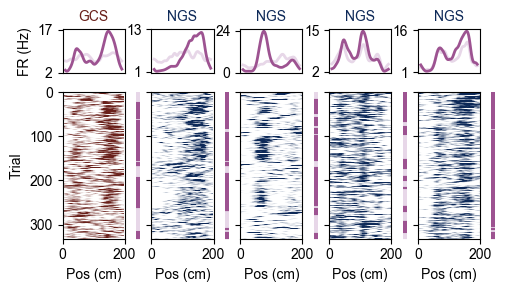

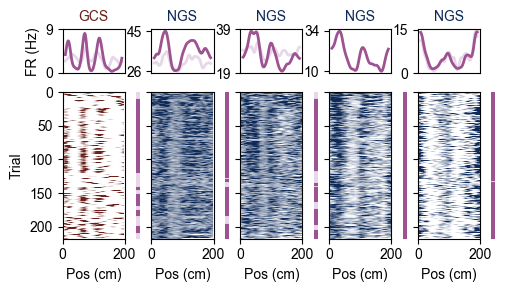

In [49]:
# --- Plot WITHOUT speed column ---
for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(mice, days, 
                                                                   example_cluster_ids, 
                                                                   example_cluster_labels, 
                                                                   example_cluster_colors):
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]

    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

    n_cells = len(cluster_ids)
    n_cols = 2 * n_cells
    width_ratios = [w for _ in range(n_cells) for w in [1, 0.1]]

    fig, axes = plt.subplots(
        nrows=2, ncols=n_cols,
        figsize=(rm_figsize[0] * 5.6, rm_figsize[1] * 1.7),
        gridspec_kw={'height_ratios': [0.3, 1], 'width_ratios': width_ratios},
    )

    for i, (cell_id, label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
        col_main = 2 * i
        col_scatter = 2 * i + 1

        ax_avg = axes[0, col_main]
        ax_rate = axes[1, col_main]
        ax_scatter = axes[1, col_scatter]
        axes[0, col_scatter].axis('off')

        tc = tcs[cell_id] if cell_id in tcs else None
        if tc is None:
            continue
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc}
        tcs_to_use[1000] = tc
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3]
        S = spectrograms.mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels_ta = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8","#9d5391"]):
            mask = (labels_ta == label_val)
            if np.sum(mask) > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(label, fontsize=10, color=color)
        ax_avg.set_xticks([])

        # FR(Hz) y axis: floor(min) and ceil(max) of plotted traces
        if avg_ys:
            all_y = np.concatenate(avg_ys)
            fr_min = int(np.floor(np.nanmin(all_y)))
            fr_max = int(np.ceil(np.nanmax(all_y)))
            ax_avg.set_yticks([fr_min, fr_max])

        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
        raster = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster, aspect='auto', cmap=cmap, norm=norm, interpolation='none',
                    extent=[*ax_rate.get_xlim(), ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]), ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')

        for label_val, plot_color in zip([False, True], ["#e7d7e8","#9d5391"]):
            mask = (labels_ta == label_val)
            ax_scatter.scatter(
                np.zeros(np.sum(mask)),
                np.arange(len(labels_ta))[mask],
                color=plot_color, rasterized=True, s=5, marker="_",
            )
        ax_scatter.axis('off')

    for i in range(n_cells):
        col = (i*2)+1
        axes[1, col].set_ylim(0, len(labels_ta))
        axes[1, col].invert_yaxis()
        col = i*2
        if i != 0:
            axes[1, col].set_yticklabels([])

    axes[0, 0].set_ylabel('FR (Hz)')
    axes[1, 0].set_ylabel('Trial')
    plt.subplots_adjust(wspace=0.3, hspace=0.2)
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}example_rate_maps_multishank.pdf')
    plt.show()


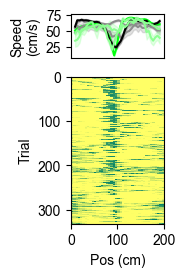

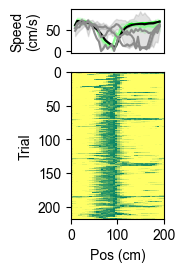

In [36]:
# --- Speed column only (same height as rate map plot) ---
import matplotlib.colors as mc

def lighten_color(color, factor=0.4):
    """Blend color toward white by factor (0=unchanged, 1=white)."""
    rgb = mc.to_rgb(color)
    return tuple(1 - (1 - factor) * (1 - c) for c in rgb)

for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(mice, days,
                                                                   example_cluster_ids,
                                                                   example_cluster_labels,
                                                                   example_cluster_colors):
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )

    speed_matrix, trial_type_colors, trial_order, pos_bins = get_heatmap_and_colors(
        beh, last_ephys_bin, tl, bs, sort=False
    )
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2

    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    trial_types_order = [trial_df.loc[int(ti), 'type'] for ti in trial_order]
    trial_perfs_order = [trial_df.loc[int(ti), 'performance'] for ti in trial_order]
    type_perf_groups = {}
    for i, (tt, perf) in enumerate(zip(trial_types_order, trial_perfs_order)):
        if str(tt) == 'nan':
            continue
        type_perf_groups.setdefault((tt, perf), []).append(i)

    fig, axes = plt.subplots(
        nrows=2, ncols=1,
        figsize=(rm_figsize[0] * 1.2, rm_figsize[1] * 1.7),
        gridspec_kw={'height_ratios': [0.3, 1]},
    )

    # --- Avg speed (row 0): one trace per (type, performance) ---
    ax_speed_avg = axes[0]
    for (tt, perf), rows in type_perf_groups.items():
        data = speed_matrix[rows, :]
        mean = np.nanmean(data, axis=0)
        se = sem_nan(data, axis=0)
        base_color = get_color_for_group(('rz1', tt, 'hit'))
        color = base_color if perf == 'hit' else lighten_color(base_color, factor=0.55)
        ax_speed_avg.plot(pos_centers, mean, color=color)
        ax_speed_avg.fill_between(pos_centers, mean - se, mean + se, color=color, alpha=0.25)
    ax_speed_avg.set_ylabel('Speed\n(cm/s)')
    ax_speed_avg.set_xticks([])

    # --- Speed heatmap (row 1) ---
    ax_speed_heatmap = axes[1]
    ax_speed_heatmap.pcolormesh(
        pos_bins, np.arange(len(trial_order) + 1),
        np.nan_to_num(speed_matrix, nan=0),
        cmap='summer', shading='auto', vmin=0, vmax=60,
        rasterized=True
    )
    ax_speed_heatmap.set_xlabel('Pos (cm)')
    ax_speed_heatmap.set_ylabel('Trial')
    ax_speed_heatmap.set_xlim(0, tl)
    ax_speed_heatmap.set_ylim(0, len(trial_order))
    ax_speed_heatmap.invert_yaxis()

    plt.subplots_adjust(hspace=0.2)
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}speed_only.pdf')
    plt.show()


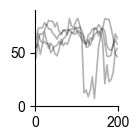

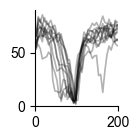

In [74]:

mice = [26, 25]
days = [19, 25]
trials_to_plot = [np.arange(130, 140),
                  np.arange(120, 140)]

for mouse, day, trial_numbers_to_plot in zip(mice, days, trials_to_plot):
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    speed_matrix, trial_type_colors, trial_order, pos_bins = get_heatmap_and_colors(
        beh, last_ephys_bin, tl, bs, sort=False
    )
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2

    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    number_to_row = {
        int(trial_df['number'][ti]): row_idx
        for row_idx, ti in enumerate(trial_order)
    }

    fig, ax = plt.subplots(figsize=(1.5, 1.5))

    for trial_num in trial_numbers_to_plot:
        row = number_to_row.get(trial_num)
        if row is None:
            continue
        ti = trial_order[row]
        trial_type = trial_df.loc[int(ti), 'type']
        if str(trial_type) != 'nb':
            continue
        profile = speed_matrix[row, :]
        ax.plot(pos_centers, profile, color='black', alpha=0.3, linewidth=1.2)

    ax.set_xlim(0, tl)
    ax.set_ylim(0, 90)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
        f'figure_3_xgboost/M{mouse}D{day}speed_selected_trials.pdf'
    )
    plt.show()


In [55]:

mouse = 26
day = 19
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')

plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, 
                                                           label='GC', figpath=f'/Users/harryclark/Desktop/M{mouse}D{day}')
for shank in [0,1,2,3]:
    cluster_ids = ngs[ngs['shank_id'] == shank].cluster_id.values
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=cluster_ids, 
                                                               label=f'NGS Shank {shank}', 
                                                               figpath=f'/Users/harryclark/Desktop/M{mouse}D{day}')